# Arrow Maze Choice Task — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)  

This notebook demonstrates how to access each data stream in the Arrow Maze Choice Task NWB files.

## About the experiment

Water-restricted mice navigated a modified T-maze (40×40 cm box with transparent floor)
with two lateral corridors branching from a central corridor. Only the left corridor was
rewarded (3 µL water drop). Mice were trained over 4 consecutive days in 10-minute sessions.

Two cohorts were tested:
- **6-OHDA** — dopamine lesion model (WT mice, `tmaze_6ohda` sub-experiment, 14 mice × 4 days = 56 sessions)
- **Anxa1-TetTox** — genetic dopamine neuron ablation model (`tmaze_anxa1_tet`, 28 mice × 4 days = 112 sessions)

Sessions were recorded from below at 30 fps using an Oryx 10GigE camera (Hamamatsu Photonics).
Pose estimation was performed using DeepLabCut.

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Video** | `acquisition/Video {name}` | 30 fps | External reference to MP4 file (not embedded) |
| **Pose estimation** | `processing/behavior/PoseEstimationDeepLabCut` | 30 Hz | DeepLabCut output — 8 keypoints (x, y, confidence) |

## Figure correspondence

| Notebook section | Manuscript figure | What is shown |
|-----------------|-------------------|---------------|
| § 2 Pose estimation | Fig. 7A (schematic) | Body-part trajectories during maze navigation |
| § 3 Locomotion speed | Fig. 7B | Linear speed computed from body-center keypoint (cm/s) |

## Setup

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a stub (truncated) file
for quick testing; full files have the same structure with longer time series.

In [31]:
nwb_path = "../../../nwb_output/arrow_maze_choice_task/nwb_stub/sub-502041_ses-tmaze-6ohda-day01.nwb"

io = NWBHDF5IO(nwb_path, mode="r")
nwbfile = io.read()

print(f"Session ID:         {nwbfile.session_id}")
print(f"Session start:      {nwbfile.session_start_time}")
print(f"Session desc:       {nwbfile.session_description[:80]}...")
print(f"Subject ID:         {nwbfile.subject.subject_id}")
print(f"Species:            {nwbfile.subject.species}")
print(f"Genotype:           {nwbfile.subject.genotype}")
print(f"Sex:                {nwbfile.subject.sex}")
print(f"Institution:        {nwbfile.institution}")
print(f"Lab:                {nwbfile.lab}")
print(f"Related pubs:       {nwbfile.related_publications}")

Session ID:         tmaze-6ohda-day01
Session start:      2022-03-22 15:08:03+01:00
Session desc:       Arrow maze choice task (T-maze) session. A water-restricted mouse navigated a T-...
Subject ID:         502041
Species:            Mus musculus
Genotype:           WT
Sex:                U
Institution:        Karolinska Institutet
Lab:                Meletis
Related pubs:       ('doi:10.1101/2024.12.22.629963',)


## 1. Video (external reference)

Videos are stored as external file references rather than embedded pixel data.
Each session has one MP4 video (H.264, 30 fps, ~856×818 pixels) recorded from below
through a transparent floor. The `external_file` field contains the absolute path to
the video on the original acquisition disk.

In [22]:
video_keys = [k for k in nwbfile.acquisition if "Video" in k]

if video_keys:
    video = nwbfile.acquisition[video_keys[0]]
    print(f"Video name:      {video.name}")
    print(f"External file:   {video.external_file[0]}")
    print(f"Starting time:   {video.starting_time} s")
    print(f"Rate:            {video.rate} fps")
    print(f"Description:     {video.description}")
else:
    print("No video found in this NWB file.")

Video name:      Video tmaze_2022-03-22T15_08_03
External file:   /Volumes/T9/data/Meletis/tmaze/videos/tmaze_2022-03-22T15_08_03.mp4
Starting time:   0.0 s
Rate:            30.0 fps
Description:     Video recorded by camera.


## 2. Pose estimation (DeepLabCut)

Pose estimation was performed using DeepLabCut, tracking 8 keypoints on each mouse:
**snout**, **head**, **body**, **left front paw**, **right front paw**, **left back paw**,
**right back paw**, and **tail base**. Stored via the
[ndx-pose](https://github.com/rly/ndx-pose) extension.

Each keypoint has:
- `data` — (N, 2) array of (x, y) pixel coordinates at 30 Hz
- `confidence` — (N,) array of DLC likelihood scores per frame

Scorer: `DLC_resnet50_completeArrowMazeDec9shuffle1_1000000`

In [23]:
behavior = nwbfile.processing["behavior"]
pose = behavior["PoseEstimationDeepLabCut"]

keypoint_names = list(pose.pose_estimation_series.keys())
print(f"Keypoints ({len(keypoint_names)}):")
for kp in keypoint_names:
    pes = pose.pose_estimation_series[kp]
    conf = pes.confidence[:]
    print(f"  {kp.replace('PoseEstimationSeries', ''):20s}  shape={str(pes.data.shape):12s}  "
          f"conf_mean={conf.mean():.3f}")

print(f"\nScorer:          {pose.scorer}")
print(f"Source software: {pose.source_software}")

Keypoints (8):
  Body                  shape=(18000, 2)    conf_mean=0.987
  Head                  shape=(18000, 2)    conf_mean=0.711
  Leftbackpaw           shape=(18000, 2)    conf_mean=0.991
  Leftfrontpaw          shape=(18000, 2)    conf_mean=0.857
  Rightbackpaw          shape=(18000, 2)    conf_mean=0.991
  Rightfrontpaw         shape=(18000, 2)    conf_mean=0.876
  Snout                 shape=(18000, 2)    conf_mean=0.800
  Tailbase              shape=(18000, 2)    conf_mean=0.981

Scorer:          DLC_resnet50_completeArrowMazeDec9shuffle1_1000000
Source software: DeepLabCut


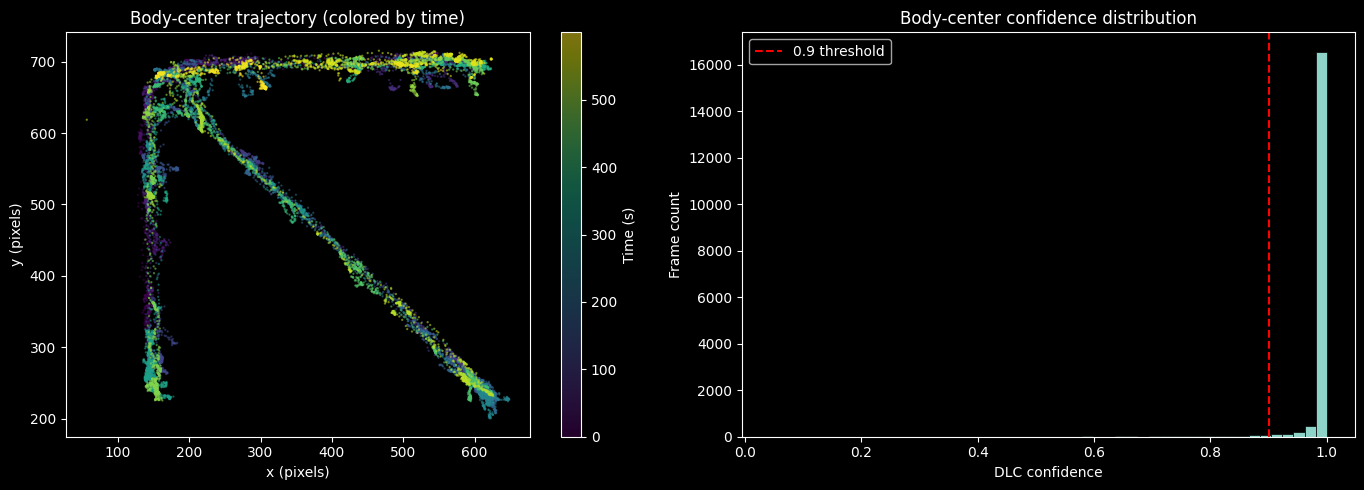

In [24]:
# Plot body-center trajectory colored by time
body = pose.pose_estimation_series["PoseEstimationSeriesBody"]
body_xy = body.data[:]
n_frames = len(body_xy)
fps = body.rate  # 30.0 Hz
time_s = np.arange(n_frames) / fps

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trajectory colored by time
ax = axes[0]
sc = ax.scatter(body_xy[:, 0], body_xy[:, 1], c=time_s, s=0.5, cmap="viridis", alpha=0.5)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Body-center trajectory (colored by time)")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="Time (s)")

# Confidence histogram
conf = body.confidence[:]
ax = axes[1]
ax.hist(conf, bins=50, edgecolor="black", linewidth=0.5)
ax.set_xlabel("DLC confidence")
ax.set_ylabel("Frame count")
ax.set_title("Body-center confidence distribution")
ax.axvline(0.9, color="red", linestyle="--", label="0.9 threshold")
ax.legend()

plt.tight_layout()
plt.show()

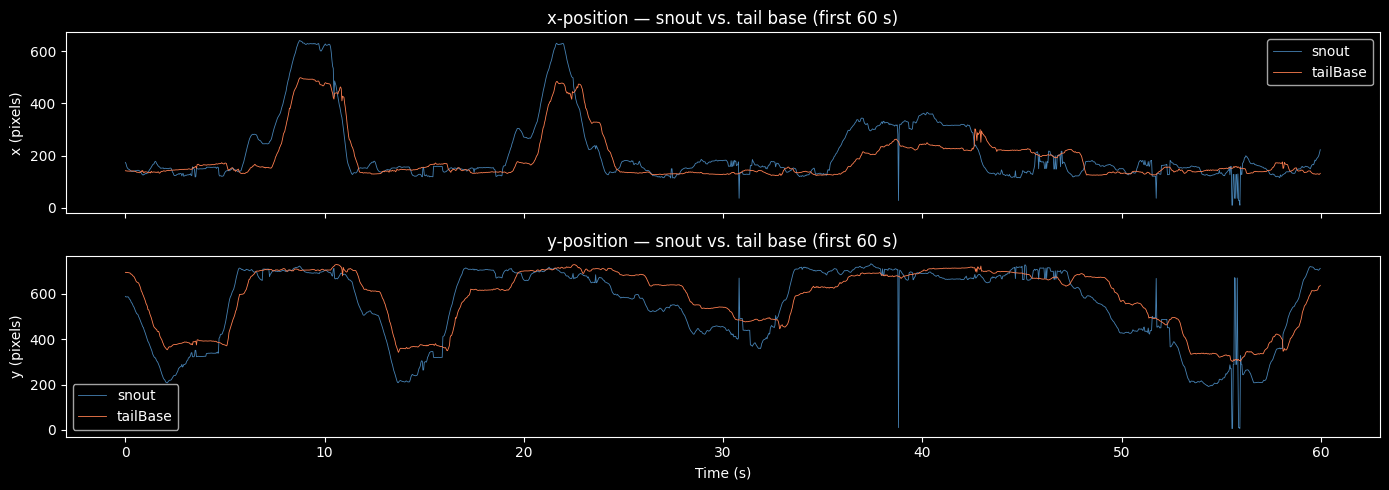

In [25]:
# Compare snout vs tail-base x-position over time (first 60 s)
snout = pose.pose_estimation_series["PoseEstimationSeriesSnout"]
tailbase = pose.pose_estimation_series["PoseEstimationSeriesTailbase"]

t_end = 60  # seconds
n_show = int(t_end * fps)
t = np.arange(n_show) / fps

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t, snout.data[:n_show, 0], linewidth=0.6, color="steelblue", label="snout")
axes[0].plot(t, tailbase.data[:n_show, 0], linewidth=0.6, color="coral", label="tailBase")
axes[0].set_ylabel("x (pixels)")
axes[0].set_title("x-position — snout vs. tail base (first 60 s)")
axes[0].legend()

axes[1].plot(t, snout.data[:n_show, 1], linewidth=0.6, color="steelblue", label="snout")
axes[1].plot(t, tailbase.data[:n_show, 1], linewidth=0.6, color="coral", label="tailBase")
axes[1].set_ylabel("y (pixels)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("y-position — snout vs. tail base (first 60 s)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. NWB file structure overview

Summary of all containers in this NWB file.

## 3. Locomotion speed (cf. Fig. 7B)

Figure 7B of Mantas et al. (2024) reports linear locomotion speed during arrow maze sessions
and shows that Anxa1-TetTox and 6-OHDA mice have reduced speed on the final training day
compared to controls.

The speed can be computed directly from the body-center DLC keypoint:
frame-to-frame Euclidean displacement × frame rate. We convert from pixels to cm using
the known arena size (40 cm × 40 cm, 856 × 818 px → ~21 px/cm).

In [26]:
# Arena dimensions: 40 cm × 40 cm, video resolution 856 × 818 px
# Average scale factor across x and y dimensions
px_per_cm = (856 / 40 + 818 / 40) / 2  # ~20.9 px/cm
CONF_THRESHOLD = 0.6  # exclude low-confidence frames

body = pose.pose_estimation_series["PoseEstimationSeriesBody"]
body_xy = body.data[:].copy().astype(float)
body_conf = body.confidence[:]
fps = body.rate  # 30.0 Hz

# Mask low-confidence frames as NaN so they don't contribute to displacement
body_xy[body_conf < CONF_THRESHOLD] = np.nan

# Frame-to-frame displacement → instantaneous speed in cm/s
# np.diff propagates NaN, so any transition involving a masked frame is excluded
displacement_px = np.sqrt(np.nansum(np.diff(body_xy, axis=0) ** 2, axis=1))
# Also NaN-out transitions where either endpoint was masked
valid = np.isfinite(body_xy[:-1]).all(axis=1) & np.isfinite(body_xy[1:]).all(axis=1)
speed_cm_s = np.where(valid, displacement_px * fps / px_per_cm, np.nan)

# Time axis (length = n_frames - 1)
time_s = np.arange(len(speed_cm_s)) / fps

print(f"Confidence threshold: {CONF_THRESHOLD}  ({(~valid).sum()} / {len(valid)} frames masked)")
print(f"Mean speed:   {np.nanmean(speed_cm_s):.2f} cm/s")
print(f"Median speed: {np.nanmedian(speed_cm_s):.2f} cm/s")
print(f"Max speed:    {np.nanmax(speed_cm_s):.2f} cm/s")
print(f"% immobile (< 1 cm/s): {np.nanmean(speed_cm_s < 1) * 100:.1f}%")

Confidence threshold: 0.6  (161 / 17999 frames masked)
Mean speed:   3.96 cm/s
Median speed: 2.34 cm/s
Max speed:    64.85 cm/s
% immobile (< 1 cm/s): 17.4%


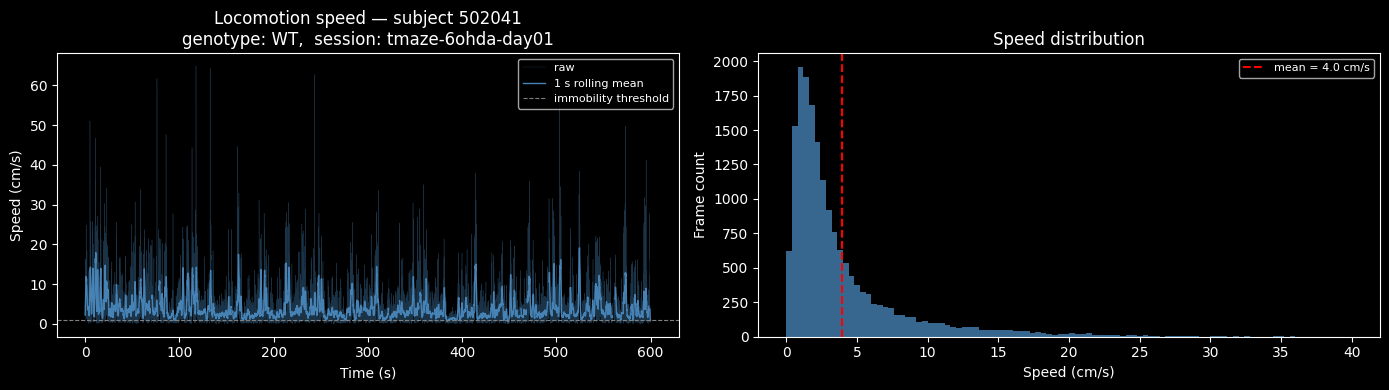

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full-session speed trace (smoothed with 1 s rolling average for clarity)
window = int(fps)  # 30-frame (1 s) rolling mean
speed_smooth = np.convolve(speed_cm_s, np.ones(window) / window, mode="same")

axes[0].plot(time_s, speed_cm_s, linewidth=0.3, color="steelblue", alpha=0.4, label="raw")
axes[0].plot(time_s, speed_smooth, linewidth=1.0, color="steelblue", label="1 s rolling mean")
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="immobility threshold")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Speed (cm/s)")
axes[0].set_title(
    f"Locomotion speed — subject {nwbfile.subject.subject_id}\n"
    f"genotype: {nwbfile.subject.genotype},  session: {nwbfile.session_id}"
)
axes[0].legend(fontsize=8)

# Speed distribution
axes[1].hist(speed_cm_s, bins=100, range=(0, 40), color="steelblue", edgecolor="none", alpha=0.8)
axes[1].axvline(np.nanmean(speed_cm_s), color="red", linestyle="--", label=f"mean = {np.nanmean(speed_cm_s):.1f} cm/s")
axes[1].set_xlabel("Speed (cm/s)")
axes[1].set_ylabel("Frame count")
axes[1].set_title("Speed distribution")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
print("=== Acquisition ===")
for name, obj in nwbfile.acquisition.items():
    print(f"  {name}: {type(obj).__name__}")

print("\n=== Processing ===")
for mod_name, module in nwbfile.processing.items():
    print(f"  {mod_name}/")
    for name, obj in module.data_interfaces.items():
        print(f"    {name}: {type(obj).__name__}")

print("\n=== Devices ===")
for name in nwbfile.devices:
    print(f"  {name}")

print("\n=== Subject ===")
s = nwbfile.subject
print(f"  subject_id: {s.subject_id}")
print(f"  species:    {s.species}")
print(f"  genotype:   {s.genotype}")
print(f"  sex:        {s.sex}")

=== Acquisition ===
  Video tmaze_2022-03-22T15_08_03: ImageSeries

=== Processing ===
  behavior/
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons

=== Devices ===
  CameraPoseEstimationDeepLabCut
  Oryx 10GigE Camera

=== Subject ===
  subject_id: 502041
  species:    Mus musculus
  genotype:   WT
  sex:        U


In [29]:
io.close()